<center> <img src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fmiro.medium.com%2Fmax%2F450%2F1*CXZ804tKLPy2hiikJbYH3w.png&f=1&nofb=1" width=25% > </center>

<br><br>

<center> 
    <font size="6">Lab 4: </font> 
</center>
<center> 
    <font size="4">Computer Vision 1 University of Amsterdam</font> 
</center>
<center> 
    <font size="4">Due 23:59PM, October 4, 2024 (Amsterdam time)</font> 
</center>
<center> 
    <font size="4"><b>TA's: Egoitz & Roan</b></font>
</center>

<br><br>

***

<br><br>

<center>

Student1 ID:  \
Student1 Name: 

Student2 ID: \
Student2 Name: 

Student3 ID: \
Student3 Name: 

( Student4 ID: \
Student4 Name: )

</center>

### **Import Libraries**

In [1]:
import sys

if sys.version_info[0] < 3:
    raise Exception("Python 3 or a more recent version is required.")

In [2]:
# environment and libraries
import os
import math
import time
import cv2
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import random

from tqdm.notebook import tqdm
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import signal
from matplotlib.patches import ConnectionPatch

In [3]:
# Make sure you're using the provided environment!
assert cv2.__version__ == "4.10.0", "You're not using the provided Python environment!"
assert np.__version__ == "1.26.4", "You're not using the provided Python environment!"
assert matplotlib.__version__ == "3.9.2", "You're not using the provided Python environment!"
# Proceed to the next cell if you don't get any error.

### **Instructions**

Your code and discussion must be handed in this jupyter notebook, renamed to **StudentID1_StudentID2_StudentID3.ipynb** before the deadline by submitting it to the Canvas Lab 4 Assignment. Please also fill out your names and ID's above.

For full credit, make sure your notebook follows these guidelines:
- It is mandatory to **use the Python environment provided** with the assignment; the environment specifies the package versions that have to be used to prevent the use of particular functions. Using different packages versions may lead to grade deduction. In the Python cell above you can check whether your environment is set up correctly.
- To install the environment with the right package versions, use the following command in your terminal: ```conda env create --file=CV1_environment.yaml```, then activate the environment using the command ```conda activate cv1```.
- Do not use additional packages or materials that have not been provided or explicitly mentioned.
- Please express your thoughts **concisely**. The number of words does not necessarily correlate with how well you understand the concepts.
- Answer all given questions and sub-questions.
- Try to understand the problem as much as you can. When answering a question, give evidences (qualitative and/or quantitative results, references to papers, figures etc.) to support your arguments. Note that not everything might be explicitly asked for and you are expected to think about what might strengthen you arguments and make the notebook self-contained and complete.
- Tables and figures must be accompanied by a **brief** description. Do not forget to add a number, a title, and if applicable name and unit of variables in a table, name and unit of axes and legends in a figure.

__Note:__ A more complete overview of the lab requirements can be found in the Course Manual on Canvas

Late submissions are not allowed. Assignments that are submitted after the strict deadline will not be graded. In case of submission conflicts, TAs’ system clock is taken as reference. We strongly recommend submitting well in advance, to avoid last minute system failure issues.

Plagiarism note: Keep in mind that plagiarism (submitted materials which are not your work) is a serious crime and any misconduct shall be punished with the university regulations. This includes the use of generative tools such as ChatGPT.

**ENSURE THAT YOU SAVE ALL RESULTS / ANSWERS ON THE QUESTIONS (EVEN IF YOU RE-USE SOME CODE).**

### **Overview**

- [Section X: Individual Contribution Report (Mandatory)](#section-x)

<a id="section-1"></a>
### **Section 1: Image Alignment**

In this section, you will develop a function that computes the affine transformation between two images. The goal is to align two supplied images from *Genoa Beach* by following a series of steps that involve detecting interest points, characterizing their local appearances, and matching these regions between the images. This process is fundamental in many computer vision tasks, such as object recognition, image stitching, and motion tracking.

The overall procedure is outlined as follows:

1. **Detect Interest Points:**
   - Identify key points in each image that are likely to be matched between the two images.

2. **Characterize Local Appearance:**
   - Describe the local appearance around each interest point using a region descriptor.

3. **Find Matches:**
   - Match the region descriptors between the two images to identify corresponding points. You can use David Lowe's SIFT (Scale-Invariant Feature Transform) for these steps. SIFT is a powerful method for detecting and describing local features in images. For further information, refer to the [SIFT tutorial](https://docs.opencv.org/3.4.2/da/df5/tutorial_py_sift_intro.html) and the [SIFT class documentation](https://docs.opencv.org/3.4.2/d5/d3c/classcv_1_1xfeatures2d_1_1SIFT.html).

4. **Perform RANSAC (Random Sample Consensus):**
   - To find the best transformation, perform the following steps:
     - **Repeat N times:**
       - Randomly select a set of P matched pairs from the total set of matches.
       - Construct a matrix A and vector b using the P pairs of points. Solve for the affine transformation parameters \((m1, m2, m3, m4, t1, t2)\) by solving the equation \(Ax = b\). This equation can be solved using the pseudo-inverse \(x = (A^T A)^{-1} A^T b\) or by using Python's Numpy package.
       - Apply the transformation to all matched points in the first image. If the transformation is accurate, the transformed points should lie close to their corresponding points in the second image.
       - Count the number of inliers, where inliers are defined as points from the first image that, when transformed, lie within a radius of 10 pixels from their corresponding points in the second image.
       - If the number of inliers exceeds the best count so far, save the transformation parameters and the set of inliers.

5. **Visualize RANSAC Performance:**
   - Plot the two images side by side and draw lines connecting the original points in the first image with their corresponding transformed points in the second image.

6. **Transform the First Image:**
   - Use the final set of transformation parameters to transform the first image. The transformed image should align with the second image. Implement this transformation using **nearest-neighbor interpolation**. Additionally, use OpenCV's built-in function `cv2.warpAffine` to compare results. Note that nearest-neighbor interpolation involves rounding the coordinates of the transformed points, which is simpler to implement than linear interpolation.


<a id="question-1"></a>
#### <font color='#FF0000'>Question 1 (5 points)</font>

Create a function named **get_matching_keypoints()** that takes two images as input and returns the matching keypoints between them.

The function should use the SIFT (Scale-Invariant Feature Transform) algorithm to detect and describe keypoints in both images. Once the keypoints are detected, use a brute-force matcher with Euclidean distance to find and return the matches between the two images. Make sure to convert the images to grayscale for processing.

The function should return the keypoints detected in the first image, the keypoints detected in the second image, and the matches found between them. Ensure that the function prints the number of keypoints detected in each image, as well as the number of matches found.

To test your function, use the images `genoa_beach.jpg` and `genoa_beach_cut_1.jpg`.

In [4]:
def get_matching_keypoints(image_1, image_2):
    """
    Given two input images, find and return the matching keypoints.

    Args:
        image_1: The first image (in RGB)
        image_2: The second image (in RGB)

    Returns:
        keypoints_image_1: Keypoints detected in the first image
        keypoints_image_2: Keypoints detected in the second image
        matches: Matching keypoints between the two images
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    print('Finding matching features...')

    # Convert images to grayscale for SIFT processing
    image_1_gray = cv2.cvtColor(image_1, cv2.COLOR_RGB2GRAY)
    image_2_gray = cv2.cvtColor(image_2, cv2.COLOR_RGB2GRAY)

    # Initialize the SIFT detector
    sift = cv2.SIFT_create()

    # Detect keypoints and compute their descriptors using SIFT
    keypoints_image_1, descriptors_image_1 = sift.detectAndCompute(image_1_gray, None)
    keypoints_image_2, descriptors_image_2 = sift.detectAndCompute(image_2_gray, None)

    # Initialize a brute-force matcher with Euclidean distance and cross-check
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)

    # Match descriptors between the two images
    matches = matcher.match(descriptors_image_1, descriptors_image_2)

    # Output the number of keypoints and matches
    print(f"Number of keypoints in the first image:  {len(keypoints_image_1)}")
    print(f"Number of keypoints in the second image: {len(keypoints_image_2)}")
    print(f"Number of matches: {len(matches)}")

    ## <<< SOLUTION

    return keypoints_image_1, keypoints_image_2, matches

In [5]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/genoa_beach.jpg')
# image_1 = cv2.imread('images/sp1.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/genoa_beach_cut_1.jpg')
# image_2 = cv2.imread('images/sp2.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Find matching keypoints
keypoints_image_1, keypoints_image_2, matches = get_matching_keypoints(image_1, image_2)

## <<< SOLUTION

Finding matching features...
Number of keypoints in the first image:  14514
Number of keypoints in the second image: 10245
Number of matches: 6416


<a id="question-2"></a>
#### <font color='#FF0000'>Question 2 (10 points)</font>

Create a function named `draw_random_matches` that takes the matching keypoints found in Question 1, selects a random subset of 10 matching points, and plots them on the images.

The function should connect matching pairs with lines, assigning a random color to each line to make them easier to distinguish. Ensure that the keypoints are marked on both images and that the matching lines are clearly visible. The images should be displayed side by side for easy comparison.

**Hint:** Use `from matplotlib.patches import ConnectionPatch` for drawing the lines between matching keypoints.

In [6]:
def draw_random_matches(image_1, keypoints_1, image_2, keypoints_2, matches, subset_size=10):
    """
    Draw a random subset of matching keypoints between two images.

    Args:
        image_1: The first image (in RGB)
        keypoints_1: Keypoints detected in the first image
        image_2: The second image (in RGB)
        keypoints_2: Keypoints detected in the second image
        matches: Matching keypoints between the two images
        subset_size: Number of random matches to display (default is 10)

    Returns:
        None. The function displays the images with the matching keypoints.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Randomly select a subset of matches
    selected_matches = random.sample(matches, subset_size)

    # Set up the subplot arrangement
    fig, axes = plt.subplots(1, 2, figsize=(15, 15))
    axes[0].imshow(image_1)
    axes[0].axis('off')
    axes[1].imshow(image_2)
    axes[1].axis('off')

    # Extract the indices of the selected keypoints
    idx1 = [m.queryIdx for m in selected_matches]
    idx2 = [m.trainIdx for m in selected_matches]

    # Extract the x and y coordinates of the selected keypoints
    x_1 = [keypoints_1[i].pt[0] for i in idx1]
    y_1 = [keypoints_1[i].pt[1] for i in idx1]
    x_2 = [keypoints_2[i].pt[0] for i in idx2]
    y_2 = [keypoints_2[i].pt[1] for i in idx2]

    # Plot the keypoints on the images
    axes[0].scatter(x_1, y_1, marker='x', color='r')
    axes[1].scatter(x_2, y_2, marker='x', color='r')

    # Add titles to the images
    axes[0].set_title('Image 1')
    axes[1].set_title('Image 2')

    # Draw circles and arrows around the selected keypoints only
    for i in range(subset_size):
        kp1 = keypoints_1[idx1[i]]
        kp2 = keypoints_2[idx2[i]]

        # First image: Draw circle and arrow for each keypoint
        x1, y1 = kp1.pt
        radius1 = kp1.size * 20
        angle1 = kp1.angle / (2 * np.pi)
        axes[0].add_artist(plt.Circle((x1, y1), radius1, fill=False))
        axes[0].add_artist(plt.Arrow(x1, y1, radius1 * np.cos(angle1), radius1 * np.sin(angle1), color='red'))

        # Second image: Draw circle and arrow for each keypoint
        x2, y2 = kp2.pt
        radius2 = kp2.size * 15
        angle2 = kp2.angle / (2 * np.pi)
        axes[1].add_artist(plt.Circle((x2, y2), radius2, fill=False))
        axes[1].add_artist(plt.Arrow(x2, y2, radius2 * np.cos(angle2), radius2 * np.sin(angle2), color='red'))

        # Draw a line connecting the matching keypoints
        connection = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color=(random.uniform(0, 1), random.uniform(0, 1), random.uniform(0, 1))
        )
        axes[1].add_artist(connection)

    plt.show()

    ## <<< SOLUTION

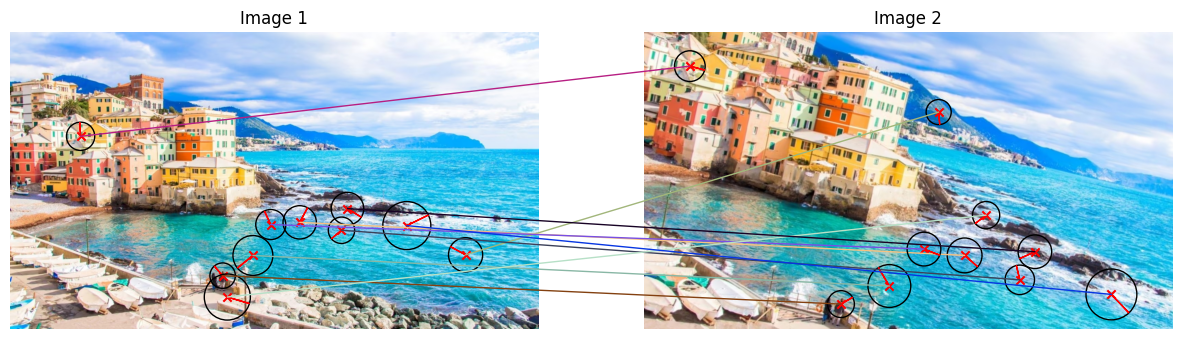

In [7]:
draw_random_matches(image_1, keypoints_image_1, image_2, keypoints_image_2, matches, subset_size=10)

<a id="question-3"></a>
#### <font color='#FF0000'>Question 3 (15 points)</font>

In this question, you will implement the RANSAC algorithm to filter out outlier matches between two sets of keypoints by fitting a projective transformation model. You have to complete the following functions:

1. **compute_projective_transformation_matrix:** This function takes a set of point correspondences and computes a projective transformation matrix using those points.
2. **test_projective_transformation_matrix:** This function tests the computed projective transformation matrix on a set of point correspondences and identifies the inliers based on a given threshold.
3. **ransac_algorithm:** This function applies the RANSAC algorithm to find the best projective transformation matrix by repeatedly sampling points and testing the model.

In [8]:
def compute_projective_transformation_matrix(data):
    """
    Compute a projective transformation matrix using a set of point correspondences.

    Args:
        data: An array containing point correspondences between two images.

    Returns:
        transformation_matrix: A projective transformation matrix.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Initialize matrices A and b
    A = np.empty((0, 6))
    b = np.empty((0, 1))

    # Loop through the point correspondences and construct the system of equations
    for (x, y), (xp, yp) in data:

        # Add two rows for each correspondence to matrix A
        A = np.vstack((A, [x, y, 0, 0, 1, 0]))
        A = np.vstack((A, [0, 0, x, y, 0, 1]))

        # Add the corresponding output coordinates to vector b
        b = np.vstack((b, [xp]))
        b = np.vstack((b, [yp]))

    # Solve the system of equations Ax = b using the normal equation
    # to minimize the least squares error
    if np.linalg.det(A.T @ A) == 0:
        transformation_matrix = np.zeros((6,1))
    else:
        transformation_matrix = np.linalg.inv(A.T @ A) @ A.T @ b

    # Convert the transformation coefficients into a 2x3 matrix
    transformation_matrix = transformation_matrix.flatten()
    transformation_matrix = np.array([[transformation_matrix[0], transformation_matrix[1], transformation_matrix[4]],
                                      [transformation_matrix[2], transformation_matrix[3], transformation_matrix[5]]])

    ## <<< SOLUTION

    return transformation_matrix

In [9]:
def test_projective_transformation_matrix(transformation_matrix, data, threshold=10):
    """
    Test the projective transformation matrix on a set of point correspondences 
    and identify inliers.

    Args:
        transformation_matrix: A projective transformation matrix.
        data: An array containing point correspondences.
        threshold: The distance threshold to consider a transformed point as 
                   an inlier. Default is 10.

    Returns:
        inliers: A list of indices of the inliers within the input data.
    """

    inliers = []

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Loop through each point correspondence
    for idx, ((xi, yi), (xa, ya)) in enumerate(data):
        
        # Transform the point from the first image using the projective matrix
        point = np.array([xi, yi, 1]).T
        x, y = transformation_matrix @ point

        # Compute the Euclidean distance between the transformed point and 
        # the corresponding point in the second image
        # If the distance is below the threshold, consider this correspondence as an inlier
        if np.sqrt((x - xa) ** 2 + (y - ya) ** 2) < threshold:
            inliers.append(idx)

    ## <<< SOLUTION

    return inliers

In [10]:
def ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations, num_points=3, threshold=10):
    """
    Apply the RANSAC algorithm to filter out outlier matches between two sets of 
    keypoints by fitting a projective transformation model.

    Args:
        keypoints_1: The keypoints from the first image.
        keypoints_2: The keypoints from the second image.
        matches: A list of matches between keypoints_1 and keypoints_2.
        num_iterations: The number of iterations for the RANSAC algorithm.
        num_points: The number of points to randomly sample in each iteration 
                    to fit the model. Default is 3.
        threshold: The distance threshold to consider a matched pair as an 
                   inlier. Default is 10.

    Returns:
        best_transformation_matrix: The best transformation matrix found by RANSAC. 
                                    None may be returned if the matrix cannot be computed.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    best_transformation_matrix = None
    result_models = []
    result_inliers = []
    num_inliers = []

    # Extract point coordinates from the keypoints using match indices
    data = [((keypoints_1[match.queryIdx].pt), (keypoints_2[match.trainIdx].pt)) for match in matches]
    data = np.array(data)

    for _ in range(num_iterations):

        # Randomly sample num_points pairs of points
        sample = random.choices(data, k=num_points)

        # Fit the projective model using the sampled points
        fitted_model = compute_projective_transformation_matrix(sample)

        # Identify inliers by testing the fitted model with all data points
        inliers = test_projective_transformation_matrix(fitted_model, data, threshold)

        # Store results of this iteration
        result_models.append(fitted_model)
        result_inliers.append(inliers)
        num_inliers.append(len(inliers))

    # Select the model that has the maximum number of inliers
    best_idx = np.argmax(np.array(num_inliers))

    # Re-fit the model using all inliers from the best iteration
    best_transformation_matrix = compute_projective_transformation_matrix(data[result_inliers[best_idx]])
    best_inliers = num_inliers[best_idx]

    # Print information
    print("Total number of matches: ", len(matches))
    print("Inliers found:           ", best_inliers)
    print("Outliers removed:        ", len(matches) - best_inliers)

    ## <<< SOLUTION

    return best_transformation_matrix

In [11]:
num_iterations = 30
num_points = 3
threshold = 10

# YOUR CODE HERE

## >>> SOLUTION

# Apply RANSAC to find the best transformation matrix
best_transformation_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, num_iterations, num_points, threshold)

# Print the best matrix
print(f'\nBest matrix:\n{best_transformation_matrix}')

## <<< SOLUTION

Total number of matches:  6416
Inliers found:            5425
Outliers removed:         991

Best matrix:
[[ 1.11517857e+00 -2.60154331e-01 -4.23200153e+01]
 [ 2.60307651e-01  1.11474429e+00 -3.11907461e+02]]


<a id="question-5"></a>
#### <font color='#FF0000'>Question 4 (5 points)</font>

In this question, you will implement an affine transformation on an image using the transformation matrix obtained from the RANSAC algorithm in the previous question.

Create a function named `apply_affine_transformation` that takes an image and a 2x3 affine transformation matrix as input. The function should perform the affine transformation using either forward or inverse warping, based on the specified method.

Ensure that the transformed image maintains the same dimensions as the input image. The function should handle cases where the transformed coordinates go out of bounds by ignoring those pixels. You can use the resulting transformation matrix from Question 4 as the input for this function.

In [12]:
def apply_affine_transformation(image, transformation_matrix, warp_method='forward'):
    """
    Perform an affine transformation on an image.

    Args:
        image: Input image, expected shape (height, width, [channels])
        transformation_matrix: 2x3 affine transformation matrix
        warp_method: Either 'forward' or 'inverse' for the desired warping method. Default is 'forward'.

    Returns:
        transformed_image: Transformed image of the same shape as input
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Get image dimensions
    height, width = image.shape[:2]

    # Generate grid of (x, y) coordinates
    x_coords = np.tile(np.arange(width), height)
    y_coords = np.repeat(np.arange(height), width)
    homogeneous_coords = np.stack([x_coords, y_coords, np.ones_like(x_coords)], axis=0)

    # If inverse warping, invert the transformation matrix
    if warp_method == 'inverse':
        homogeneous_matrix = np.vstack([transformation_matrix, [0, 0, 1]])
        inverse_matrix = np.linalg.inv(homogeneous_matrix)
        transformation_matrix = inverse_matrix[:2, :]

    # Apply the affine transformation
    transformed_coords = np.dot(transformation_matrix, homogeneous_coords)
    transformed_coords = np.round(transformed_coords).astype(int)

    # Initialize the output image
    transformed_image = np.zeros_like(image)

    if warp_method == 'forward':
        # Forward warping: Ensure the transformed coordinates are within image bounds
        x_transformed = np.clip(transformed_coords[0], 0, width - 1)
        y_transformed = np.clip(transformed_coords[1], 0, height - 1)
        transformed_image[y_transformed, x_transformed] = image[y_coords, x_coords]
    else:
        # Inverse warping: Use np.where to find valid indices within the bounds
        x_transformed = transformed_coords[0]
        y_transformed = transformed_coords[1]

        # Get indices where transformed coordinates are within bounds
        valid_indices = np.where((x_transformed >= 0) & (x_transformed < width) &
                                 (y_transformed >= 0) & (y_transformed < height))

        # Map only the valid pixels to the transformed image
        transformed_image[y_coords[valid_indices], x_coords[valid_indices]] = \
            image[y_transformed[valid_indices], x_transformed[valid_indices]]

    ## <<< SOLUTION

    return transformed_image

<a id="question-6"></a>
#### <font color='#FF0000'>Question 5 (5 points)</font>

Create a function named **visualize_affine_transformations()** that takes the source image, reference image, and the best transformation matrix as inputs, and visualizes the results using four different methods: forward warping, inverse warping, OpenCV’s `warpAffine`, and the original reference image.

The function should display the results in a 2x4 grid of subplots:
- The first row will display the full images transformed by each method.
- The second row will display a zoomed-in section of each transformation for closer inspection.

Ensure that the subplots are well-labeled and that the zoomed-in sections provide a clear view of the differences between the methods.

In [13]:
def visualize_affine_transformations(source_image, reference_image, transformation_matrix):
    """
    Compare different affine transformation methods in a 2x4 grid visualization.

    Args:
        source_image: Source image to transform
        reference_image: Reference image to compare against
        transformation_matrix: Best transformation matrix

    Returns:
        None. Displays a plot without returning a value.
    """

    # Define the zoomed-in area (for example, the central region)
    zoom_box = (slice(50, 150), slice(50, 150))  # Adjust the slice as needed

    # Create a 2x4 grid for visualization
    fig, axes = plt.subplots(2, 4, figsize=(25, 10))

    # YOUR CODE HERE

    ## >>> SOLUTION

    # List of warp methods and titles
    warp_methods = ['forward', 'inverse', 'opencv', 'original']
    titles = ['Forward Warping', 'Inverse Warping', "OpenCV's warpAffine", 'Reference Image']

    # Loop through each warp method to process and plot images
    for i, (warp_method, title) in enumerate(zip(warp_methods, titles)):

        # Apply the selected transformation
        if warp_method == 'forward':
            transformed_image = apply_affine_transformation(source_image, transformation_matrix, warp_method='forward')

        elif warp_method == 'inverse':
            transformed_image = apply_affine_transformation(source_image, transformation_matrix, warp_method='inverse')
            
        elif warp_method == 'opencv':
            transformed_image = cv2.warpAffine(source_image, transformation_matrix, (source_image.shape[1], source_image.shape[0]))
            
        elif warp_method == 'original':
            transformed_image = reference_image

        # Plot the full image
        axes[0, i].imshow(transformed_image, cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(title)

        # Plot the zoomed-in image
        axes[1, i].imshow(transformed_image[zoom_box], cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f'Zoomed-In {title}')

    # Display the grid
    plt.show()

    ## <<< SOLUTION

Total number of matches:  6416
Inliers found:            5425
Outliers removed:         991


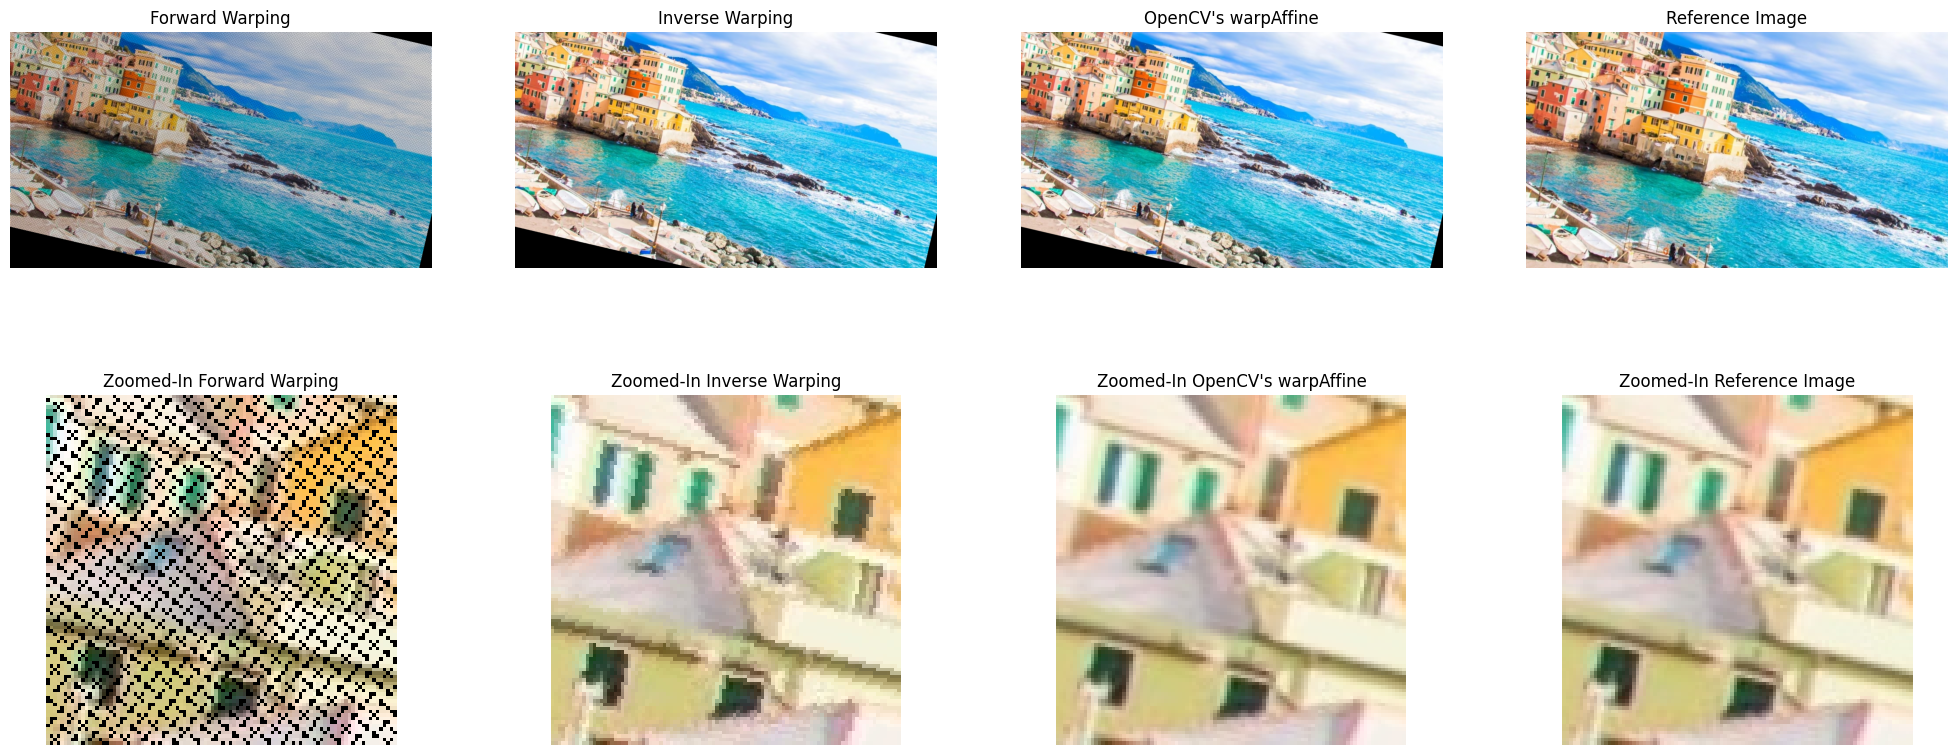

In [14]:
num_iterations = 30
num_points = 3
threshold = 10

# YOUR CODE HERE

## >>> SOLUTION

# Apply RANSAC to find the best transformation matrix
best_transformation_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, num_iterations, num_points, threshold)

# Visualize the different affine transformation methods
visualize_affine_transformations(image_1, image_2, best_transformation_matrix)

## <<< SOLUTION

<a id="question-6"></a>
#### <font color='#FF0000'>Question 6 (2 points)</font>

How many matches are required to solve an affine transformation formulated as follows:

$
\begin{bmatrix}
x'\\y'
\end{bmatrix} =
\begin{bmatrix}
m_1 & m_2\\
m_3 & m_4
\end{bmatrix}
\begin{bmatrix}
x\\y
\end{bmatrix} +
\begin{bmatrix}
t_1\\t_2
\end{bmatrix}
$

This equation can be rewritten as:

$
\begin{bmatrix}
x&y&0&0&1&0\\
0&0&x&y&0&1
\end{bmatrix}
\begin{bmatrix}
m_1\\
m_2\\
m_3\\
m_4\\
t_1\\
t_2
\end{bmatrix} =
\begin{bmatrix}
x'\\y'
\end{bmatrix}
$

Alternatively:

$
Ax = b, \;
A = \begin{bmatrix}
x&y&0&0&1&0\\
0&0&x&y&0&1
\end{bmatrix}, \;
x = \begin{bmatrix}
m_1\\
m_2\\
m_3\\
m_4\\
t_1\\
t_2
\end{bmatrix}, \;
b = \begin{bmatrix}
x'\\y'
\end{bmatrix}
$

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
> 
> - **Number of Unknowns:** The affine transformation has 6 unknowns: $m_1$, $m_2$, $m_3$, $m_4$, $t_1$, and $t_2$.
> 
> - **Number of Equations:** Each point match provides 2 equations.
> 
> - **Required Matches:** To solve for the 6 unknowns, 3 point matches are required, since 3 point matches will provide the necessary 6 equations.


<a id="question-7"></a>
#### <font color='#FF0000'>Question 7 (4 points)</font>

What happens if we have more point matches than the minimum required for solving an affine transformation? Will the code still work, and why?

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
>
> - **Code Adaptation:** If there are more point matches than the minimum required, the code needs to be adapted by vertically stacking the equations for matrices $A$ and $b$.
>
> - **Solution Approach:** With more than the minimum required matches, there likely won't be a closed-form solution. Instead, the least squares solution should be found using the pseudo-inverse of matrix $A$.
>
> - **Reasoning:** The pseudo-inverse allows us to minimize the error in over-determined systems, which occurs when more equations than unknowns are available.


<a id="question-8"></a>
#### <font color='#FF0000'>Question 8 (4 points)</font>

How many iterations are required in RANSAC to reliably find the correct transformation parameters? Provide a detailed explanation, and use mulitple figures to support your answer.

##### <font color='yellow'>Answer:</font>

> Your answer here.

> ***FOR GRADING - Answers may include:***
>
> - **Understanding of RANSAC Formula:** The student correctly uses the formula $1 - p = (1 - w^n)^k$ to calculate the required number of iterations ($k$) in RANSAC. They explain the variables: $p$ (desired probability), $n$ (number of points sampled per iteration), and $w$ (probability of selecting an inlier).
>
> - **Calculation and Explanation:** 
>   - The student correctly calculates $k$ using the formula $k = \frac{\log(1 - p)}{\log(1-w^n)}$.
>   - They identify $n = 5$, with 6416 matches, 5423 inliers, and $w \approx 0.845$.
>   - They provide $k$ values for different probabilities:
>     - $p = 99.99\%$, $k \approx 16$
>     - $p = 50\%$, $k \approx 1$
>
> - **Interpretation of Results:**
>   - The student correctly interprets that with 8 iterations, there's a very high probability (99.99%) of finding a match.
>   - They note that with 3 iterations, the probability is 90%, and with fewer than 2 iterations, the probability drops below 50%.
>   - The answer references an experiment that supports the calculations, noting that from about 3 iterations, a good transformation is consistently found.
>
> - **Overall Understanding:** The student demonstrates a clear understanding of how the number of iterations impacts the success rate of RANSAC in finding correct transformation parameters.

Number of iterations: 1
Total number of matches:  6416
Inliers found:            5422
Outliers removed:         994
Number of iterations: 3
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 5
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 7
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 10
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 15
Total number of matches:  6416
Inliers found:            5423
Outliers removed:         993
Number of iterations: 60
Total number of matches:  6416
Inliers found:            5424
Outliers removed:         992
Number of iterations: 100
Total number of matches:  6416
Inliers found:            5425
Outliers removed:         991


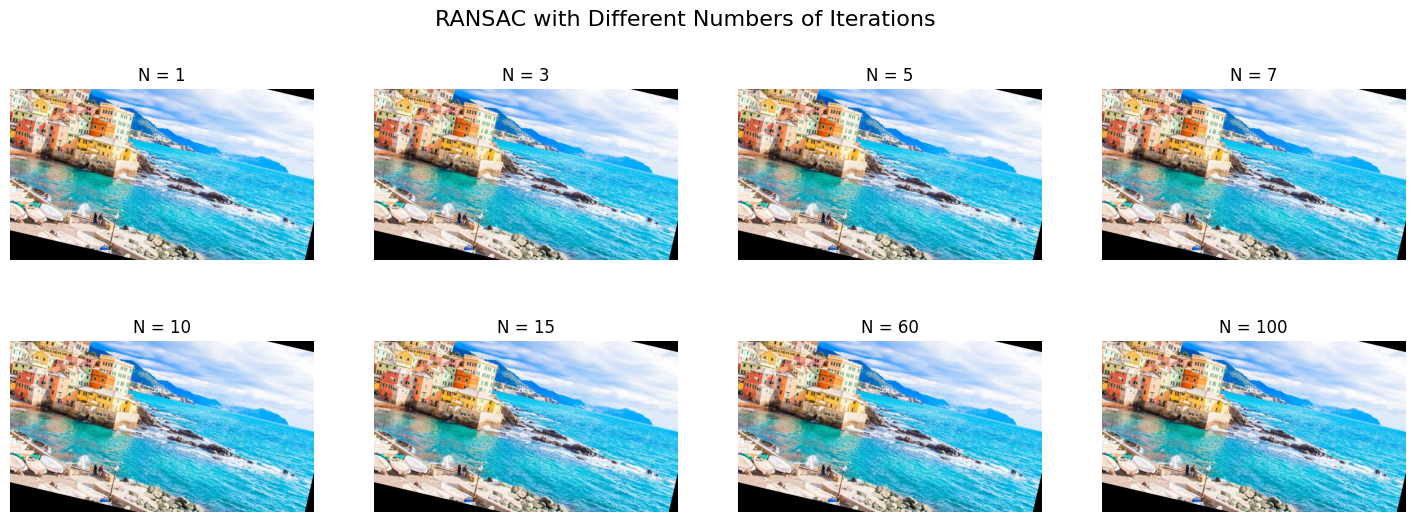

In [15]:
# YOUR CODE HERE

## >>> SOLUTION

# Sample arrays representing some values for iterations in RANSAC
NS1 = [1, 3, 5, 7]
NS2 = [10, 15, 60, 100]

# Combining the sample arrays into a numpy array for easy indexing
NS = np.array([NS1, NS2])

# Creating a subplot grid of 2x4 and defining the figure size
fig, axs = plt.subplots(2, 4, figsize=(18, 6))

# Looping through the 2D numpy array (2x4)
for i in range(2):
    for j in range(4):
        # Selecting the number of iterations (N) from the NS array
        N = NS[i, j]

        print(f"Number of iterations: {N}")
        # Getting the best transformation matrix by applying RANSAC on keypoints and matches
        # with the current number of iterations (N)
        best_matrix = ransac_algorithm(keypoints_image_1, keypoints_image_2, matches, N)

        # Applying an affine transformation to image_1 using the obtained best_matrix
        transformed_image = cv2.warpAffine(image_1, best_matrix, (image_1.shape[1], image_1.shape[0]))

        # Adding the transformed image to the subplot
        axs[i][j].imshow(transformed_image)
        
        # Setting title with number of iterations, total matches, and inliers
        axs[i][j].set_title(f"N = {N}")
        axs[i][j].axis('off')

# Add a title to the entire plot
fig.suptitle('RANSAC with Different Numbers of Iterations', fontsize=16)

# Displaying the entire grid of transformed images
plt.show()

## <<< SOLUTION

<a id="section-2"></a>
### **Section 2: Image Stitching**

In this section, we will explore the process of image stitching, a technique used to combine multiple images into a single, seamless panorama. This process involves aligning and blending overlapping images to create a larger, cohesive image. By determining the geometric transformation needed to align one image with another, we can map the images to a common coordinate system. Image stitching is widely used in various applications, including photography, computer vision, and virtual reality, where creating wide-angle or high-resolution images from multiple photos is essential.

<a id="question-9"></a>
#### <font color='#FF0000'>Question 9 (15 points)</font>

Create a function named **stitch_images_together()** that takes a pair of images as input and returns the stitched result. 

The function should:
- Find the best transformation between the input images using the RANSAC algorithm.
- Estimate the size of the stitched image.
- Transform one image into the coordinate space of the other.
- Combine the transformed image with the other to create a seamless panorama.

Ensure that the function correctly handles both directions—transforming the first image to the coordinate space of the second, and vice versa. The final output should be well-stitched and padded rather than cropped.

**Note:** You can use the `cv2.warpAffine` function to apply the transformation to the images. But you should implement the stitching process yourself **without** using any built-in stitching functions from OpenCV.

In [16]:
def stitch_images_together(image_1, image_2, num_iterations=100):
    """
    Given two input images, return the stitched image.

    Args:
        image_1: The first image (in RGB).
        image_2: The second image (in RGB).
        num_iterations: Number of iterations for RANSAC (default is 100).

    Returns:
        The stitched image combining the two input images.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Find matching keypoints between the two images
    keypoints_1, keypoints_2, matches = get_matching_keypoints(image_1, image_2)

    # Compute the best transformation matrix using RANSAC
    transformation_matrix = ransac_algorithm(keypoints_1, keypoints_2, matches, num_iterations)

    # Get image dimensions
    h1, w1 = image_1.shape[:2]
    h2, w2 = image_2.shape[:2]

    # Define the corner points of the first image
    corners_image_1 = np.array([[0, 0], [0, h1], [w1, 0], [w1, h1]], dtype=np.float32)

    # Transform the corners of the first image using the transformation matrix
    transformed_corners_image_1 = cv2.transform(np.array([corners_image_1]), transformation_matrix).squeeze()

    # Calculate the min and max coordinates to determine the size of the output image
    x_min, y_min = np.min(transformed_corners_image_1, axis=0).astype(int)
    x_max, y_max = np.max(transformed_corners_image_1, axis=0).astype(int)

    # Determine the size of the output stitched image
    output_width = max(x_max, w2) - min(x_min, 0)
    output_height = max(y_max, h2) - min(y_min, 0)

    # Calculate translation to handle negative coordinates
    offset_x = -min(x_min, 0)
    offset_y = -min(y_min, 0)

    # Adjust the transformation matrix to include the translation
    transformation_matrix[:, 2] += [offset_x, offset_y]

    # Warp the first image using the adjusted transformation matrix
    transformed_image_1 = cv2.warpAffine(image_1, transformation_matrix, (output_width, output_height))

    # Initialize the output image with the transformed first image
    output_image = transformed_image_1

    # Overlay the second image onto the stitched output
    output_image[offset_y:offset_y + h2, offset_x:offset_x + w2] = image_2

    ## <<< SOLUTION

    return output_image

<a id="question-10"></a>
#### <font color='#FF0000'>Question 10 (5 points)</font>

Write code to load the images `genoa_beach_cut_2.jpg` and `genoa_beach_cut_3.jpg`, stitch them together, and visualize the results. First, stitch `genoa_beach_cut_2.jpg` onto `genoa_beach_cut_3.jpg`, then perform the reverse operation by stitching `genoa_beach_cut_3.jpg` onto `genoa_beach_cut_2.jpg`. Visualize both original images and the resulting stitched images.

Finding matching features...
Number of keypoints in the first image:  5787
Number of keypoints in the second image: 5157
Number of matches: 2598
Total number of matches:  2598
Inliers found:            2000
Outliers removed:         598
Finding matching features...
Number of keypoints in the first image:  5157
Number of keypoints in the second image: 5787
Number of matches: 2598
Total number of matches:  2598
Inliers found:            2000
Outliers removed:         598


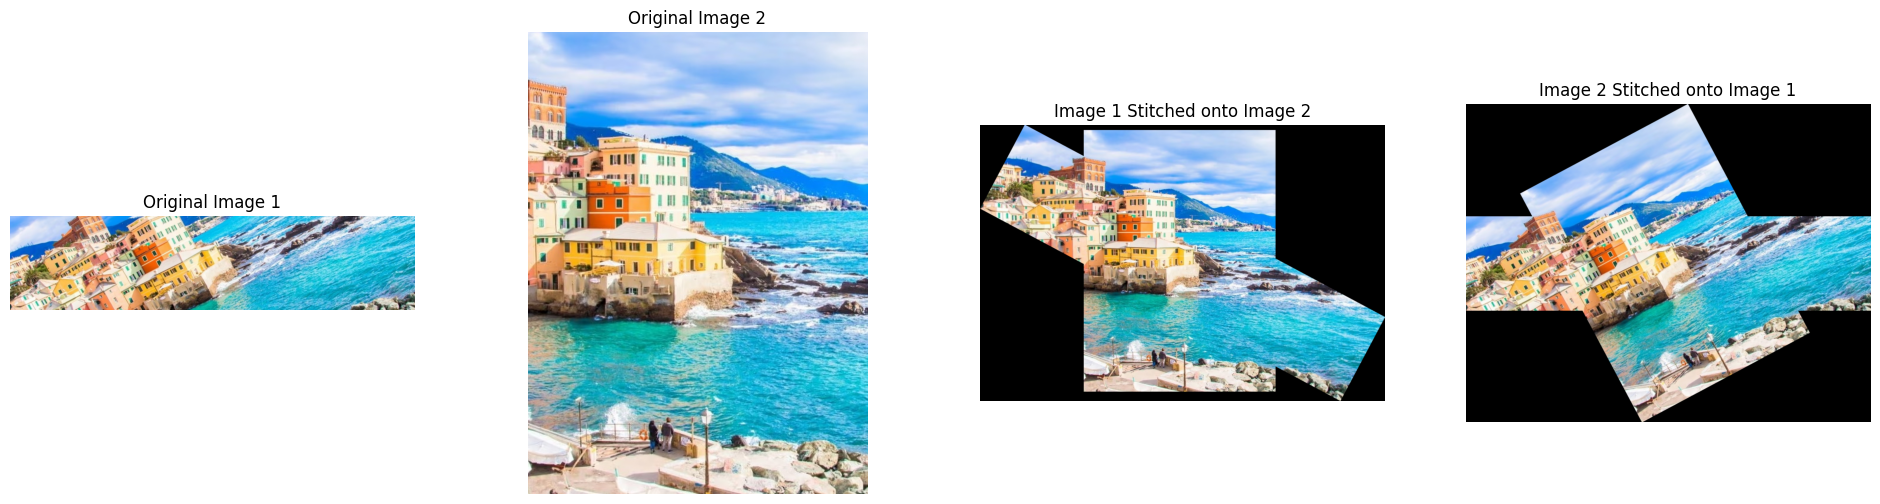

In [17]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/genoa_beach_cut_2.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/genoa_beach_cut_3.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Stitch image_1 onto image_2
stitched_image_1_onto_2 = stitch_images_together(image_1, image_2, num_iterations=100)

# Stitch image_2 onto image_1
stitched_image_2_onto_1 = stitch_images_together(image_2, image_1, num_iterations=100)

# Create a 1x4 subplot grid for displaying the results
plt.figure(figsize=(24, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_1)
plt.axis('off')
plt.title('Original Image 1')

plt.subplot(1, 4, 2)
plt.imshow(image_2)
plt.axis('off')
plt.title('Original Image 2')

plt.subplot(1, 4, 3)
plt.imshow(stitched_image_1_onto_2)
plt.axis('off')
plt.title('Image 1 Stitched onto Image 2')

plt.subplot(1, 4, 4)
plt.imshow(stitched_image_2_onto_1)
plt.axis('off')
plt.title('Image 2 Stitched onto Image 1')

plt.show()

## <<< SOLUTION

<a id="question-11"></a>
#### <font color='#FF0000'>Question 11 (5 points)</font>

Now, write code to load the images `sciencepark_1.jpg` and `sciencepark_2.jpg`, stitch them together, and visualize the results. First, stitch `sciencepark_1.jpg` onto `sciencepark_2.jpg`, then perform the reverse operation by stitching `sciencepark_2.jpg` onto `sciencepark_1.jpg`. Visualize both original images and the resulting stitched images.

Finding matching features...
Number of keypoints in the first image:  10659
Number of keypoints in the second image: 11343
Number of matches: 6218
Total number of matches:  6218
Inliers found:            5477
Outliers removed:         741
Finding matching features...
Number of keypoints in the first image:  11343
Number of keypoints in the second image: 10659
Number of matches: 6218
Total number of matches:  6218
Inliers found:            5476
Outliers removed:         742


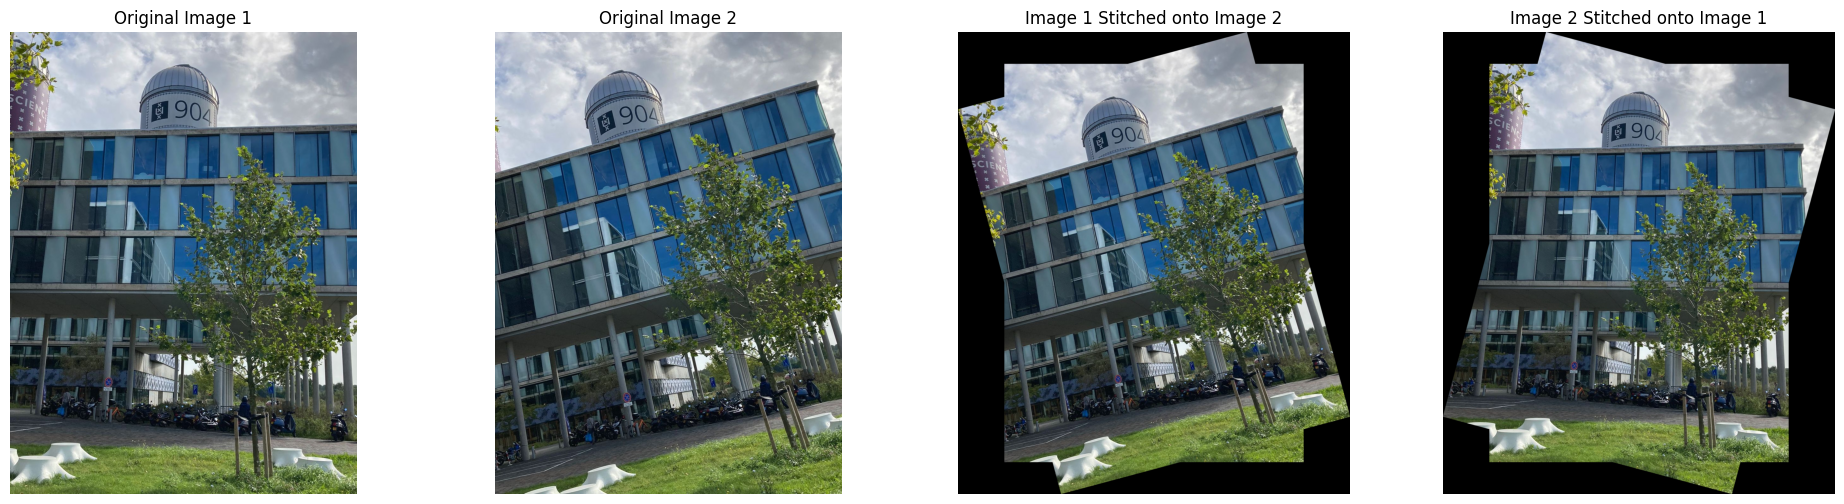

In [18]:
# YOUR CODE HERE

## >>> SOLUTION

# Load the images
image_1 = cv2.imread('images/sciencepark_1.jpg')
image_1 = cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)

image_2 = cv2.imread('images/sciencepark_2.jpg')
image_2 = cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)

# Stitch image_1 onto image_2
stitched_image_1_onto_2 = stitch_images_together(image_1, image_2, num_iterations=100)

# Stitch image_2 onto image_1
stitched_image_2_onto_1 = stitch_images_together(image_2, image_1, num_iterations=100)

# Create a 1x4 subplot grid for displaying the results
plt.figure(figsize=(24, 6))

plt.subplot(1, 4, 1)
plt.imshow(image_1)
plt.axis('off')
plt.title('Original Image 1')

plt.subplot(1, 4, 2)
plt.imshow(image_2)
plt.axis('off')
plt.title('Original Image 2')

plt.subplot(1, 4, 3)
plt.imshow(stitched_image_1_onto_2)
plt.axis('off')
plt.title('Image 1 Stitched onto Image 2')

plt.subplot(1, 4, 4)
plt.imshow(stitched_image_2_onto_1)
plt.axis('off')
plt.title('Image 2 Stitched onto Image 1')

plt.show()

## <<< SOLUTION

<a id="section-3"></a>
### **Section 3: Automatic Panorama Stitching**

In this section, you will create a panorama by stitching together multiple images. The goal is to combine a series of images into a single, wide-angle view that captures the entire scene seamlessly. This process involves detecting features in each image, matching these features between consecutive images, and computing the geometric transformations needed to align and blend them into a cohesive panorama. By mapping the images to a common coordinate system using these transformations, you can effectively stitch them together into one continuous view.

<a id="question-12"></a>
#### <font color='#FF0000'>Question 12 (30 points)</font>

Create a function named **`automatic_panorama_stitching(images, use_mask=True)`** that stitches a series of images together to create a panorama. The function should accept a list of input images and manually implement the stitching process using feature detection and matching techniques. This includes performing feature matching between images, estimating the homography between matched features, and warping images to align them into a panorama.

The function should handle cases where stitching fails, providing appropriate error messages if necessary. After stitching, and based on the **`use_mask`** parameter, the function should crop the stitched image using the bounding rectangle to remove unnecessary areas, such as black borders.

Apply your function on the image paths provided below and visualize the results for each set of images. Make sure to **also** visualize the difference between **`use_mask`** set to **True** and **False**.

```python
image_paths = [
    'panorama_images/panorama_cut_1.jpg',
    'panorama_images/panorama_cut_2.jpg',
    'panorama_images/panorama_cut_3.jpg',
    'panorama_images/panorama_cut_4.jpg',
]

image_paths = [
    'panorama_images/panorama_2_cut_1.jpg',
    'panorama_images/panorama_2_cut_2.jpg',
    'panorama_images/panorama_2_cut_3.jpg',
    'panorama_images/panorama_2_cut_4.jpg',
    'panorama_images/panorama_2_cut_5.jpg',
    'panorama_images/panorama_2_cut_6.jpg',
    'panorama_images/panorama_2_cut_7.jpg',
    'panorama_images/panorama_2_cut_8.jpg',
]
```

**Note:** You are allowed to use any of the functions you have implemented in the previous sections, but you are also allowed to use any other functions from OpenCV.

In [19]:
def automatic_panorama_stitching(images, use_mask=True):
    """
    Automatically stitch a series of images together to create a panorama.

    Args:
        images: A list of input images to stitch together.
        use_mask: A boolean indicating whether to use a mask for the final stitched image. (default is True)

    Returns:
        stitched: The final stitched image.
    """

    # YOUR CODE HERE

    ## >>> SOLUTION

    # Create a stitcher object
    stitcher = cv2.Stitcher_create()
    (status, stitched) = stitcher.stitch(images)

    if status != cv2.Stitcher_OK:
        print(f"Image stitching failed ({status})")
        return None

    # Add a 10 pixel border around the image
    stitched = cv2.copyMakeBorder(
        stitched, 10, 10, 10, 10, cv2.BORDER_CONSTANT, value=(0, 0, 0)
    )

    # Convert to grayscale and threshold
    gray = cv2.cvtColor(stitched, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)

    # Find contours in the thresholded image
    contours, _ = cv2.findContours(
        thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Find the largest contour which will be the outline of the stitched image
    c = max(contours, key=cv2.contourArea)

    # Allocate mask for rectangular bounding box of stitched image region
    mask = np.zeros(thresh.shape, dtype="uint8")
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(mask, (x, y), (x + w, y + h), 255, -1)

    # Create two copies of the mask
    minRect = mask.copy()
    sub = mask.copy()

    # Keep looping until there are no non-zero pixels left in the subtracted image
    while cv2.countNonZero(sub) > 0:
        # Erode the minimum rectangular mask and subtract
        minRect = cv2.erode(minRect, None)
        sub = cv2.subtract(minRect, thresh)

    # Find contours in the minimum rectangular mask and extract bounding box
    contours, _ = cv2.findContours(
        minRect.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    if use_mask:
        # Use the bounding box coordinates to extract the final stitched image
        stitched = stitched[y : y + h, x : x + w]

    ## <<< SOLUTION

    return stitched

Image 1 loaded successfully with shape (541, 407, 3)
Image 2 loaded successfully with shape (541, 407, 3)
Image 3 loaded successfully with shape (541, 407, 3)
Image 4 loaded successfully with shape (541, 407, 3)


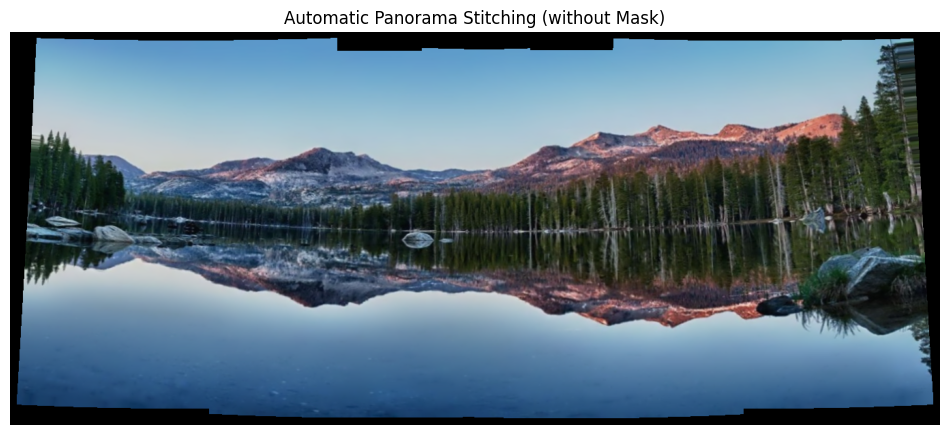

Successfully stitched panorama 2 without mask.


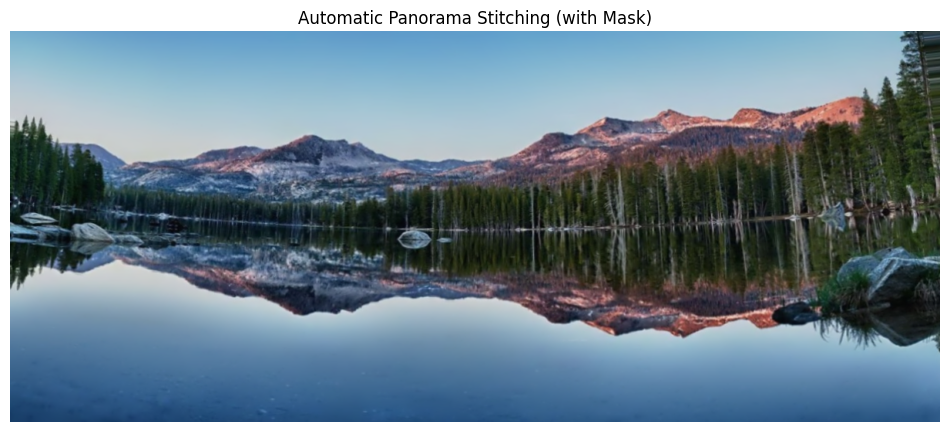

Successfully stitched panorama 2 with mask.


In [20]:
# YOUR CODE HERE

## >>> SOLUTION

# Image paths
image_paths = [
    'panorama_images/panorama_cut_1.jpg',
    'panorama_images/panorama_cut_2.jpg',
    'panorama_images/panorama_cut_3.jpg',
    'panorama_images/panorama_cut_4.jpg',
]

# Check if files exist
for path in image_paths:
    if not os.path.isfile(path):
        print(f"File not found: {path}")

# Load images
images = [cv2.imread(path) for path in image_paths]

# Verify that images are loaded
for idx, img in enumerate(images):
    if img is None:
        print(f"Image {idx+1} failed to load.")
    else:
        print(f"Image {idx+1} loaded successfully with shape {img.shape}")

# Perform automatic panorama stitching
stitched_image = automatic_panorama_stitching(images, use_mask=False)

if stitched_image is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (without Mask)')
    plt.show()
    print("Successfully stitched panorama 2 without mask.")

# Perform automatic panorama stitching
stitched_image_with_mask = automatic_panorama_stitching(images, use_mask=True)

if stitched_image_with_mask is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_with_mask, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (with Mask)')
    plt.show()
    print("Successfully stitched panorama 2 with mask.")

## <<< SOLUTION

Image 1 loaded successfully with shape (2832, 2186, 3)
Image 2 loaded successfully with shape (2832, 2186, 3)
Image 3 loaded successfully with shape (2832, 2186, 3)
Image 4 loaded successfully with shape (2832, 2186, 3)
Image 5 loaded successfully with shape (2832, 2186, 3)
Image 6 loaded successfully with shape (2832, 2186, 3)
Image 7 loaded successfully with shape (2832, 2186, 3)
Image 8 loaded successfully with shape (2832, 2186, 3)


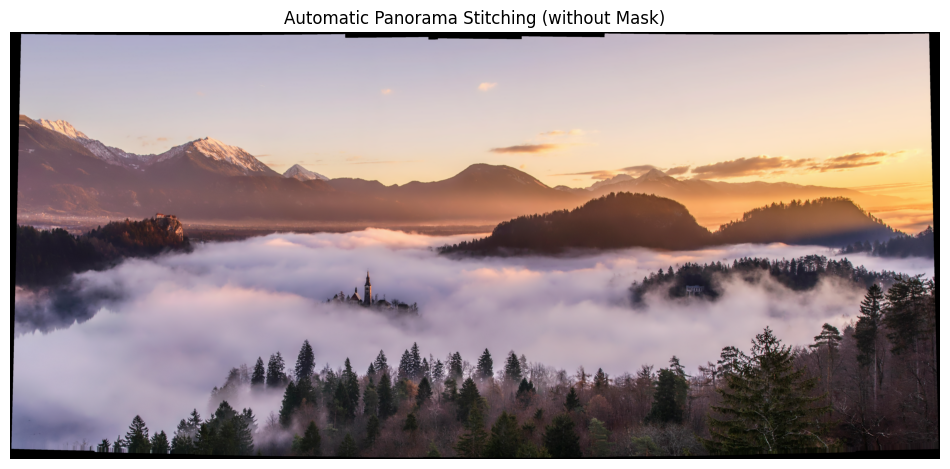

Successfully stitched panorama 2 without mask.


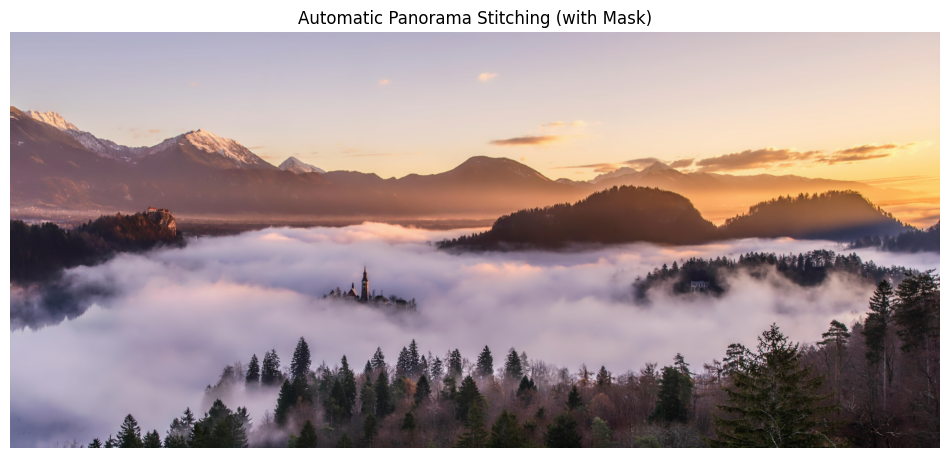

Successfully stitched panorama 2 with mask.


In [21]:
# YOUR CODE HERE

## >>> SOLUTION

# Image paths for panorama 2
image_paths_2 = [
    'panorama_images/panorama_2_cut_1.jpg',
    'panorama_images/panorama_2_cut_2.jpg',
    'panorama_images/panorama_2_cut_3.jpg',
    'panorama_images/panorama_2_cut_4.jpg',
    'panorama_images/panorama_2_cut_5.jpg',
    'panorama_images/panorama_2_cut_6.jpg',
    'panorama_images/panorama_2_cut_7.jpg',
    'panorama_images/panorama_2_cut_8.jpg',
]

# Check if files exist
for path in image_paths_2:
    if not os.path.isfile(path):
        print(f"File not found: {path}")

# Load images
images_2 = [cv2.imread(path) for path in image_paths_2]

# Verify that images are loaded
for idx, img in enumerate(images_2):
    if img is None:
        print(f"Image {idx+1} failed to load.")
    else:
        print(f"Image {idx+1} loaded successfully with shape {img.shape}")

# Perform automatic panorama stitching
stitched_image_2 = automatic_panorama_stitching(images_2, use_mask=False)

if stitched_image_2 is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_2, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (without Mask)')
    plt.show()
    print("Successfully stitched panorama 2 without mask.")

# Perform automatic panorama stitching
stitched_image_2_with_mask = automatic_panorama_stitching(images_2, use_mask=True)

if stitched_image_2_with_mask is None:
    print("Stitching failed.")
else:
    # Display the stitched image
    plt.figure(figsize=(12, 12))
    plt.imshow(cv2.cvtColor(stitched_image_2_with_mask, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title('Automatic Panorama Stitching (with Mask)')
    plt.show()
    print("Successfully stitched panorama 2 with mask.")

## <<< SOLUTION

<a id="section-x"></a>
### **Section X: Individual Contribution Report *(Mandatory)***

Because we want each student to contribute fairly to the submitted work, we ask you to fill out the textcells below. Write down your contribution to each of the assignment components in percentages. Naturally, percentages for one particular component should add up to 100% (e.g. 30% - 30% - 40%). No further explanation has to be given.

| Name | Contribution on Research | Contribution on Programming | Contribution on Writing |
| -------- | ------- | ------- | ------- |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |
|  | - % | - % | - % |

### - End of Notebook -